# Credit Card Fraud Detection — Data Analysis & Machine Learning

**Author:** Long Hua  
**Date:** March 2026

---

## Mục tiêu dự án
- **Phân tích** dữ liệu giao dịch thẻ tín dụng để phát hiện gian lận (fraud)
- **Data Cleaning**: Xử lý dữ liệu thiếu, trùng lặp, chuyển đổi kiểu dữ liệu
- **EDA**: Khám phá dữ liệu với các biểu đồ trực quan
- **Machine Learning**: Xây dựng và so sánh nhiều mô hình phân loại
- **Đánh giá**: So sánh các metrics giữa các mô hình

## Dữ liệu
- **`cc_num_dims.csv`**: Thông tin khách hàng (926 khách hàng)
- **`cc_num_trans_fact.csv`**: Giao dịch thẻ tín dụng (~555,000 giao dịch)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns 
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report, auc
)
from sklearn.metrics import ConfusionMatrixDisplay
# Advanced Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# Imbalanced Data
from imblearn.over_sampling import SMOTE

## 2. Load Data

In [2]:
dims = pd.read_csv(r'cc_num_dims.csv')
dims.head()


,cc_num,fist_name,last_name,gender,city,state,job,dob
0,180036456789979,Mackenzie,Salazar,F,Bagley,WI,Risk analyst,1974-11-20
1,180042946491150,Charles,Robles,M,Saint Petersburg,FL,"Engineer, land",1989-02-28
2,180069253480336,William,Hunter,M,Emporium,PA,Public affairs consultant,1969-11-01
3,180098888332620,Dennis,Davidson,M,Springville,NY,"Scientist, research (maths)",1959-03-30
4,213114122496591,Jeremy,Perry,M,Minnesota Lake,MN,Music tutor,1963-07-14


In [3]:
fact = pd.read_csv(r'cc_num_trans_fact.csv')
fact.head()

,trans_num,trans_date_trans_time,cc_num,amt,lat,long,category,is_fraud
0,7e501768c1082828b98ffd29d0b8b7dc,2020-06-30 20:45:52.000,6011917798331152,141.06,43.1699,-72.8515,home,0
1,f5557f1a21e74ee164360e78aff35144,2020-06-30 20:46:10.000,3577578023716568,477.59,41.0935,-81.0425,shopping_net,0
2,f2112ea42fd1a7581a6c050ffc4ccb10,2020-06-30 20:46:13.000,373043435942726,69.39,29.4790,-95.9681,entertainment,0
3,68b70cd8876b73a79a1ffef07f21da47,2020-06-30 20:46:32.000,4587577161160601,13.60,44.0943,-69.4828,entertainment,0
4,bb69e2f055b54abdecaff526196789d8,2020-06-30 20:46:38.000,213156747557083,8.07,34.1556,-118.2322,shopping_pos,0


## 3. Data Cleaning

### 3.1 Kiểm tra Missing Values


In [4]:
print(dims.isnull().sum())
print(fact.isnull().sum())


cc_num       0
fist_name    0
last_name    0
gender       0
city         0
state        0
job          0
dob          0
dtype: int64
trans_num                0
trans_date_trans_time    0
cc_num                   0
amt                      0
lat                      0
long                     0
category                 0
is_fraud                 0
dtype: int64


### 3.2 Kiểm tra Duplicates

In [5]:
print(dims.duplicated().sum())
print(fact.duplicated().sum())

0
0


### 3.3 Chuyển đổi kiểu dữ liệu & Merge

In [6]:
df= fact.merge(dims, how='left', on='cc_num')
df.head()

,trans_num,trans_date_trans_time,cc_num,amt,lat,long,category,is_fraud,fist_name,last_name,gender,city,state,job,dob
0,7e501768c1082828b98ffd29d0b8b7dc,2020-06-30 20:45:52.000,6011917798331152,141.06,43.1699,-72.8515,home,0,William,Johnson,M,South Londonderry,VT,Scientific laboratory technician,1957-08-30
1,f5557f1a21e74ee164360e78aff35144,2020-06-30 20:46:10.000,3577578023716568,477.59,41.0935,-81.0425,shopping_net,0,Debbie,Hughes,F,Diamond,OH,"Engineer, biomedical",1983-08-25
2,f2112ea42fd1a7581a6c050ffc4ccb10,2020-06-30 20:46:13.000,373043435942726,69.39,29.4790,-95.9681,entertainment,0,Vincent,Richards,M,Beasley,TX,Trading standards officer,1981-03-04
3,68b70cd8876b73a79a1ffef07f21da47,2020-06-30 20:46:32.000,4587577161160601,13.60,44.0943,-69.4828,entertainment,0,Tina,Lawrence,F,Nobleboro,ME,Financial trader,1976-04-12
4,bb69e2f055b54abdecaff526196789d8,2020-06-30 20:46:38.000,213156747557083,8.07,34.1556,-118.2322,shopping_pos,0,Adam,Santos,M,Glendale,CA,Advertising account planner,1982-07-30


In [7]:
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [8]:
df.rename(columns={'first_name':'first_name'}, inplace=True)

### 3.4 Trích xuất thông tin thời gian

Tạo các feature từ 'tran_date_trans_time':
- 'hour': giờ giao dịch
- 'day': ngày trong tháng
- 'month': tháng
- 'day_of_week': ngày trong tuần (0=Mon, 6=Sun)
- 'is_weekend': cuối tuần (Sat/Sun = 1)
- 'is_night': ban đêm (trước 5h sáng = 1)

In [9]:
# Trích xuât thông tin thời gian
df['hour'] = df['trans_date_trans_time'].dt.hour ### Tạo cột giờ từ cột thời gian giao dịch
df['day']= df['trans_date_trans_time'].dt.day ### Tạo cột ngày từ cột thời gian giao dịch
df['month']= df['trans_date_trans_time'].dt.month ### Tạo cột tháng từ cột thời gian giao dịch
df['day_of_week'] = df['trans_date_trans_time'].dt.day_of_week ### Tạo cột ngày trong tuần từ cột thời gian giao dịch
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int) ### Tạo cột cuối tuần từ cột ngày trong tuần
df['is_night'] = (df['hour'] < 5).astype(int) ### Tạo cột ban đêm từ cột giờ


### 3.5 Tính tuổi và tạo 'age_group'

In [10]:
# Tạo feature 'age' từ dob
df['age'] = pd.Timestamp.now().year - df['dob'].dt.year ### Tạo cột tuổi từ cột ngày sinh
df['age_group'] = pd.cut(df["age"],
                         bins=[18,25,35,45,55,65,200],
                         labels=['18-25','26-35','36-45','46-55','56-65','65+']) ### Tạo cột nhóm tuổi từ cột tuổi

In [11]:
# Kiểm tra lại dữ liệu sau khi đã merge và tạo feature mới
df.isnull().sum()


trans_num                0
trans_date_trans_time    0
cc_num                   0
amt                      0
lat                      0
long                     0
category                 0
is_fraud                 0
fist_name                0
last_name                0
gender                   0
city                     0
state                    0
job                      0
dob                      0
hour                     0
day                      0
month                    0
day_of_week              0
is_weekend               0
is_night                 0
age                      0
age_group                0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['age_group'].value_counts().sort_index()


age_group
18-25      8783
26-35     81524
36-45    127413
46-55    129541
56-65     84241
65+      124217
Name: count, dtype: int64

### 3.6 Tính khoảng cách từ nhà đến nơi giao dịch
Sử dụng *Haversine formula* để tính khoảng cách (km) giữa
- *Địa điểm giao dịch* (lat, long trong bảng giao dịch)  
- *Địa điểm nhà khách* (lat, long của city trong database US Cities)

In [14]:
city_coords = pd.read_csv("https://raw.githubusercontent.com/kelvins/US-Cities-Database/main/csv/us_cities.csv")

In [15]:
### Kiểm tra duplicate trong dữ liệu tọa độ thành phố
city_coords.duplicated().sum()

np.int64(0)

In [16]:
df_cities_clean= city_coords[['CITY', 'STATE_CODE', 'LATITUDE', 'LONGITUDE']].copy()
df_cities_clean.columns = ['city', 'state', 'home_lat', 'home_long']

In [17]:
df_cities_clean.groupby(['state']).agg(
    home_lat=('home_lat', 'mean'),
    home_long=('home_long', 'mean')
).reset_index()

,state,home_lat,home_long
0,AK,61.523427,-153.250867
1,AL,32.872975,-86.812472
2,AR,35.130148,-92.345102
3,AZ,33.942495,-111.459255
4,CA,36.912842,-120.156702
5,CO,39.150571,-105.419236
6,CT,41.616019,-72.696068
7,DC,38.893806,-77.016197
8,DE,39.084213,-75.490248
9,FL,28.667125,-82.423128


In [18]:
city_coords_clean = df_cities_clean.groupby(['state']).agg(
    home_lat=('home_lat', 'mean'),
    home_long=('home_long', 'mean')).reset_index()

In [19]:
df = df.merge(
    city_coords_clean,
    on=['state'],
    how='left')

In [20]:
df = df.rename(columns={
    'lat':'merchant_lat',
    'long':'merchant_long'
})

In [21]:
### Tính khoảng cách giữa nhà và nơi giao dịch bằng công thức Haversine
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lat2):
        return 0
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [22]:
# Tính khoảng cách giữa nhà và địa điểm giao dịch
df['distance_km'] = df.apply(
    lambda row: haversine(row['home_lat'], row['home_long'],
                           row['merchant_lat'], row['merchant_long']), axis=1)
df['distance_km_log'] = np.log1p(df['distance_km'])


In [23]:
median_dist = df['distance_km'].median()

In [24]:
df.isnull().sum()

trans_num                0
trans_date_trans_time    0
cc_num                   0
amt                      0
merchant_lat             0
merchant_long            0
category                 0
is_fraud                 0
fist_name                0
last_name                0
gender                   0
city                     0
state                    0
job                      0
dob                      0
hour                     0
day                      0
month                    0
day_of_week              0
is_weekend               0
is_night                 0
age                      0
age_group                0
home_lat                 0
home_long                0
distance_km              0
distance_km_log          0
dtype: int64

### 3.7 Tạo thêm feature

In [25]:
# Tạo cột khoảng cách đã được log và xử lý giá trị ngoại lai
df['log_amt'] = np.log1p(df['amt']) 

In [26]:
# Số lần giao dịch và giao dịch trung bình theo thẻ
df['trans_count'] = df.groupby('cc_num')['trans_num'].transform('count')
df["avg_amount"] = df.groupby("cc_num")["amt"].transform('mean')

In [27]:
# Sô lần giao dịch trong 1 giờ gần nhất
df = df.sort_values(["cc_num","trans_date_trans_time"]).reset_index(drop=True)
trans_count_1h = df.groupby("cc_num").rolling(
    window="1H", on="trans_date_trans_time")["amt"].count().reset_index(level=0, drop=True)
df["trans_count_1h"] = trans_count_1h.to_numpy()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\3491480514.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  trans_count_1h = df.groupby("cc_num").rolling(
C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\3491480514.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  trans_count_1h = df.groupby("cc_num").rolling(


In [28]:
# Tỷ lệ số tiền giao dịch so với trung bình giao dịch của khách hàng (giao dich bất thường so với thói quen)
df['amt_ratio'] = df['amt'] / df['avg_amount']  

In [29]:
# Top 5% giao dịch lớn nhất
df['top_5_percent'] = (df['amt'] > df['amt'].quantile(0.95)).astype(int)

## 4. EDA & Insight

In [30]:
fraud_rate = df['is_fraud'].mean() * 100
non_fraud = (df['is_fraud'] == 0).sum()

### 4.1 Phân tích theo thời gian trong ngày và trong tuần

In [31]:
# Phân tích theo thời gian trong ngày
hour_fraud = df.groupby('hour')['is_fraud'].mean().reset_index()


In [32]:
# Phân tích theo thời gian trong tuần
day_of_week_fraud = df.groupby('day_of_week')['is_fraud'].mean().reset_index()
day_of_week_fraud['day_name'] = day_of_week_fraud['day_of_week'].map({
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'})

In [33]:
# Phân tích ngày đêm
night_fraud = df.groupby('is_night')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
night_fraud['label'] = ['Day (5h-24h)', 'Night (0h-5h)']


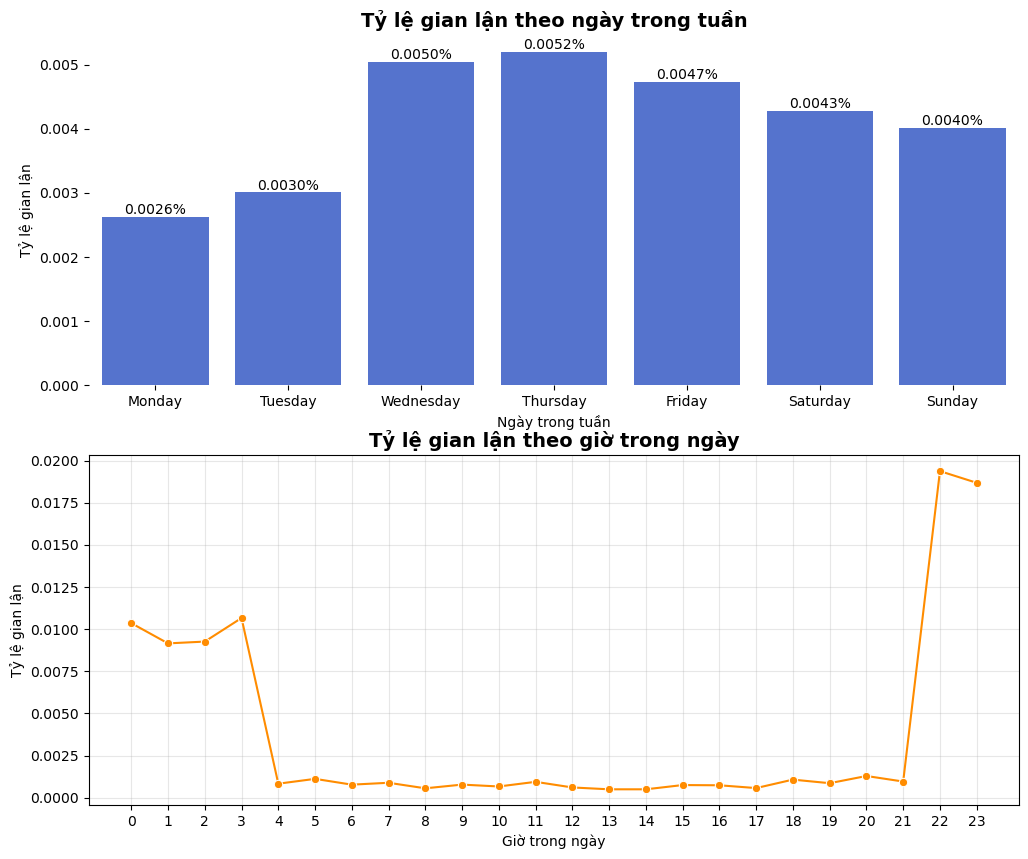

In [34]:
plt.figure(figsize=(12,10))
plt.subplot(2,1,1)
ax1 = sns.barplot(
    data=day_of_week_fraud,
    x='day_name',
    y='is_fraud',
    color='royalblue'
)
plt.xlabel('Ngày trong tuần\n')
plt.ylabel('Tỷ lệ gian lận')
plt.title('Tỷ lệ gian lận theo ngày trong tuần',
          weight='bold',
          fontsize=14)
ax1.set_frame_on(False)
for i in ax1.containers:
    ax1.bar_label(i, fmt='%.4f%%', label_type='edge')

plt.subplot(2,1,2)
sns.lineplot(
    data=hour_fraud,
    x='hour',
    y='is_fraud',
    marker='o',
    color='darkorange'
)
plt.xticks(range(0,24))
plt.ylabel('Tỷ lệ gian lận')
plt.xlabel('Giờ trong ngày')
plt.title('Tỷ lệ gian lận theo giờ trong ngày',
          weight='bold',
          fontsize=14)
plt.grid(alpha=0.3)

plt.show()

Tỷ lệ gian lận cao hơn vào buổi tối. Ngoài ra, trong tuần thì thứ tư và thứ năm có tỷ lệ gian lận cao hơn các ngày khác.

In [ ]:
heatmap = df.groupby(['day_of_week', 'hour'])['is_fraud'].mean().reset_index()

### 4.2 Phân tích theo nhóm tuổi

In [36]:

age_insight = df.groupby('age_group').agg(
    total_trans=('is_fraud', 'count'),
    fraud_cases=('is_fraud', 'sum'),
    avg_amt=('amt', 'mean')
).reset_index()
age_insight['fraud_rate'] = (age_insight['fraud_cases'] / age_insight['total_trans']) * 100


C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\1135855419.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_insight = df.groupby('age_group').agg(


C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\1624346317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_insight, x='age_group',


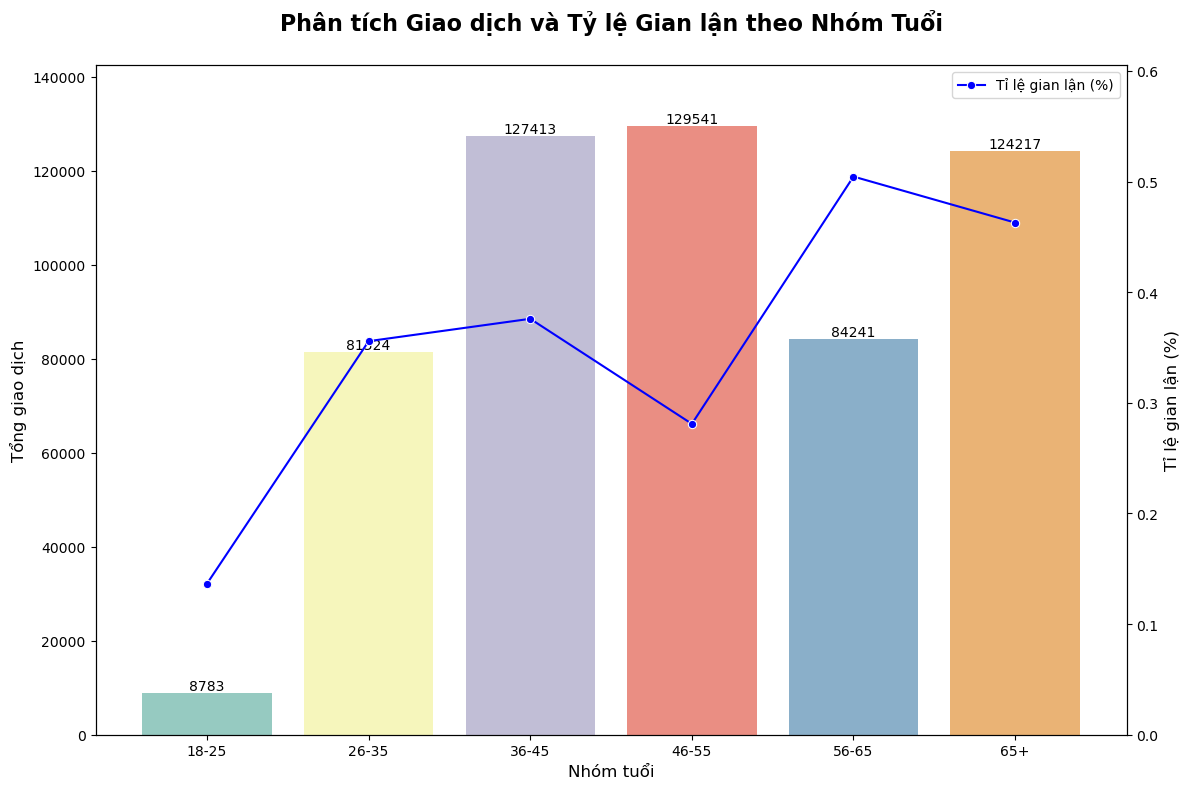

In [37]:
plt.figure(figsize=(12,8))
ax1 = plt.subplot(1,1,1)
sns.barplot(data=age_insight, x='age_group',
            y='total_trans',
            palette='Set3',
            label='Tổng giao dịch')
plt.ylabel('Tổng giao dịch',
           fontsize=12)
plt.xlabel('Nhóm tuổi',fontsize=12)
plt.title('Phân tích Giao dịch và Tỷ lệ Gian lận theo Nhóm Tuổi\n',
          weight='bold',
          fontsize=16)
for i in ax1.containers:
    ax1.bar_label(i, label_type='edge')
plt.ylim(0,age_insight['total_trans'].max() * 1.1)

plt.twinx()

ax2= sns.lineplot(data=age_insight, x='age_group',
              y='fraud_rate',
              color='blue',
              marker='o',
              label='Tỉ lệ gian lận (%)')
plt.ylabel('Tỉ lệ gian lận (%)', fontsize=12)
plt.ylim(0, age_insight['fraud_rate'].max() * 1.2)
plt.tight_layout()
plt.show()

Tỷ lệ gian lận tăng dần ở nhóm 26–35 và 36–45, giảm nhẹ ở nhóm 46–55, sau đó tăng mạnh ở nhóm 56 đến trên 65 tuổi.

### 4.3 Phân tích Theo Loại Hàng Hóa

In [38]:
category_fraud = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).reset_index()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\928552540.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=category_fraud,


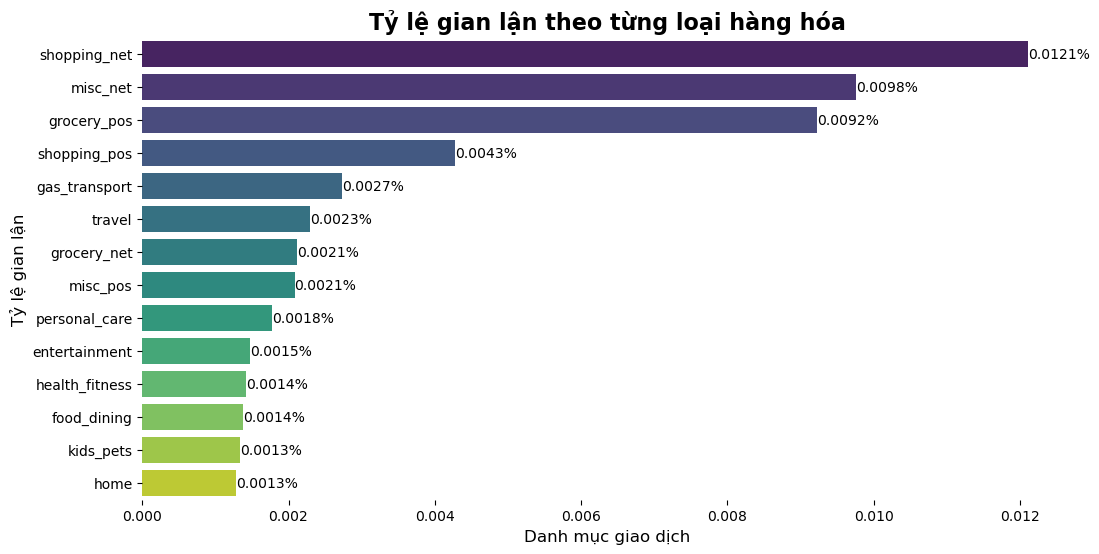

In [39]:
plt.figure(figsize=(12,6))
ax1 = sns.barplot(data=category_fraud,
                x='is_fraud', 
                y='category', 
                palette='viridis')
plt.xlabel('Danh mục giao dịch', fontsize=12)
plt.ylabel('Tỷ lệ gian lận', fontsize=12)
plt.title('Tỷ lệ gian lận theo từng loại hàng hóa', weight='bold', fontsize=16)
ax1.set_frame_on(False)
for i in ax1.containers:
    ax1.bar_label(i, fmt='%.4f%%', label_type='edge')
plt.show()

Một số category có tỷ lệ gian lận cao hơn rõ rệt, đặc biệt là:

- shopping_net
- misc_net
- grocery_pos
- shopping_pos

### 4.4 Phân tích độ xa từ nhà (Distance from Home)

In [40]:
## Tạo khoảng cách 
bins = [0, 5, 20, 100, 500, 2000]
labels = ['0-5km', '5-20km', '20-100km', '100-500km', '500km+']

df['dist_bin'] = pd.cut(
    df['distance_km'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

##Tính fraud rate theo bin
fraud_stats = df.groupby('dist_bin')['is_fraud'].agg(
    fraud_rate='mean',
    total_transactions='size',
    fraud_count='sum').reset_index()
fraud_stats = fraud_stats.sort_values('dist_bin')

C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\361454407.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_stats = df.groupby('dist_bin')['is_fraud'].agg(


In [41]:
dist_order = {
    '0-5km': 1,
    '5-20km': 2,
    '20-100km': 3,
    '100-500km': 4,
    '500km+': 5
}

fraud_stats['dist_order'] = fraud_stats['dist_bin'].map(dist_order)

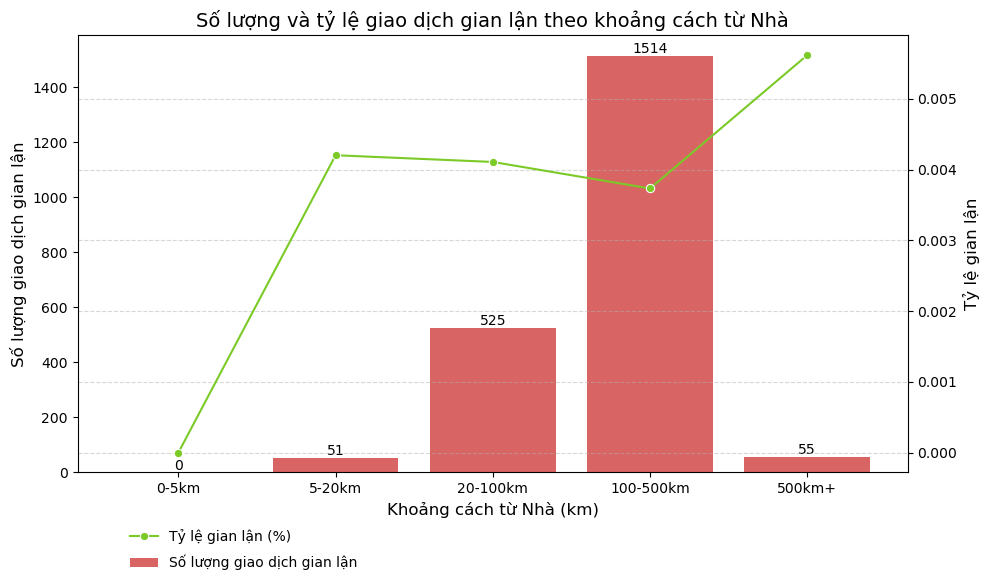

In [42]:
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=fraud_stats,
                x='dist_bin',
                y='fraud_count',
                color="#ED5050D2",
                label='Số lượng giao dịch gian lận')
plt.title('Số lượng và tỷ lệ giao dịch gian lận theo khoảng cách từ Nhà', fontsize=14)
plt.xlabel('Khoảng cách từ Nhà (km)', fontsize=12)
plt.ylabel('Số lượng giao dịch gian lận', fontsize=12)
ax1.set_frame_on(False)
for i in ax1.containers:
    ax1.bar_label(i, label_type='edge')
plt.legend(loc='upper center', 
           bbox_to_anchor=(0.2, -0.16),                       
           fontsize=10,
           frameon=False)

plt.twinx()

ax2 = sns.lineplot(data= fraud_stats,
                x='dist_bin', 
             y='fraud_rate',
             color = "#7BCA27",
             marker='o',
             label='Tỷ lệ gian lận (%)')
plt.xlabel('Khoảng cách từ Nhà (km)', fontsize=12)
plt.ylabel('Tỷ lệ gian lận', fontsize=12)
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.legend(loc='upper center', 
           bbox_to_anchor=(0.16, -0.1),                      
           fontsize=10,
           frameon=False)
plt.tight_layout()
plt.show()


Khoảng cách từ nhà khách hàng đến merchant càng xa (distance_km cao) thì xác suất gian lận càng lớn.

### 4.5 Phân tích số lần giao dịch trong giờ

In [43]:
fraud_1h = df.groupby('trans_count_1h')['is_fraud'].agg(
    fraud_rate='mean',
    total_transactions='size',
    fraud_count='sum').reset_index()
fraud_1h['fraud_rate_percent'] = fraud_1h['fraud_rate'] * 100

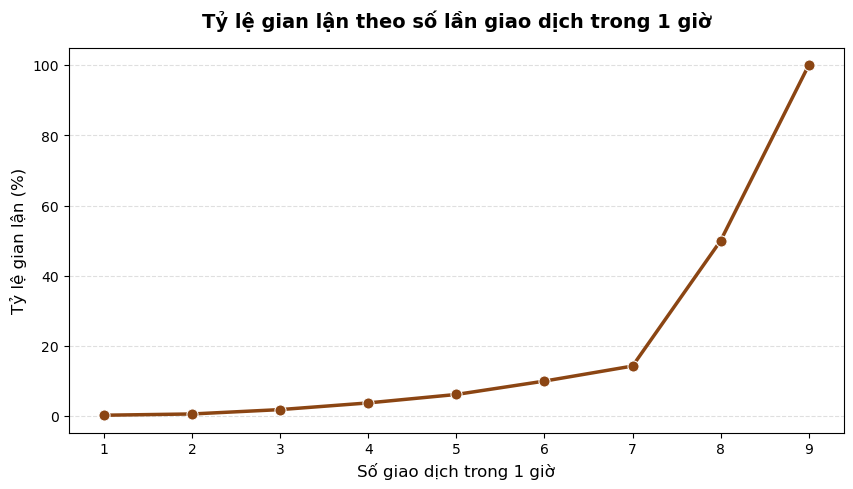

In [44]:
plt.figure(figsize=(10, 5)) 

sns.lineplot(data=fraud_1h,
             x='trans_count_1h',
             y='fraud_rate_percent',
             color='#8B4513',          
             linewidth=2.5,
             marker='o', markersize=8)
plt.title('Tỷ lệ gian lận theo số lần giao dịch trong 1 giờ', fontsize=14, pad=15,weight='bold')
plt.xlabel('Số giao dịch trong 1 giờ', fontsize=12)
plt.ylabel('Tỷ lệ gian lận (%)', fontsize=12) 
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Khi số giao dịch trong 1 giờ (trans_count_1h) tăng, tỷ lệ gian lận cũng tăng theo

### 4.6 Phân tích tỷ lệ số tiền giao dịch bất thường

In [45]:
high_amt_rate = df['top_5_percent'].groupby(df['is_fraud']).mean() * 100

C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\3156669334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=high_amt_rate.index,


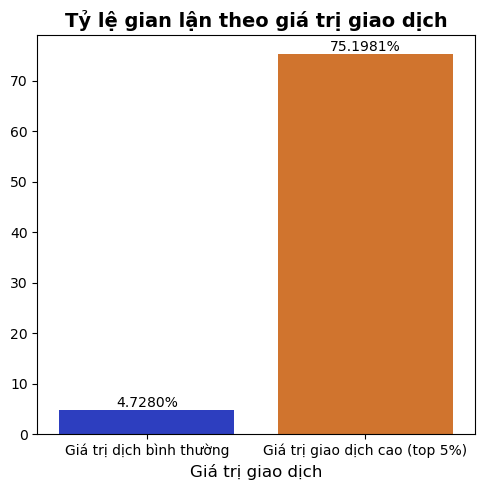

In [46]:
plt.figure(figsize=(5,5))
ax=sns.barplot(x=high_amt_rate.index,
            y=high_amt_rate.values, 
            palette=["#152BD7", "#EB7113C6"])
plt.xticks([0, 1], ['Giá trị dịch bình thường', 'Giá trị giao dịch cao (top 5%)'])
plt.xlabel('Giá trị giao dịch', fontsize=12)
plt.title('Tỷ lệ gian lận theo giá trị giao dịch', fontsize=14, weight='bold')
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f%%', label_type='edge')
plt.tight_layout()
plt.show()

Những giao dịch có số tiền cao bất thường so với mức chi tiêu bình thường của khách hàng có khả năng là gian lận cao hơn

### 4.7 Ma trận tương quan (Correlation Matrix Heatmap)

In [47]:
fraud_features = ['amt', 'log_amt', 'is_fraud', 'age',
             'hour', 'day', 'day_of_week', 'is_weekend', 'is_night',
             'distance_km', 'trans_count', 'avg_amount', 'trans_count_1h',
             'amt_ratio', 'top_5_percent']

In [48]:
df[fraud_features].describe()

,amt,log_amt,is_fraud,age,hour,day,day_of_week,is_weekend,is_night,distance_km,trans_count,avg_amount,trans_count_1h,amt_ratio,top_5_percent
count,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000
mean,69.392810,3.527641,0.003860,52.636237,12.809062,16.463904,2.726779,0.279580,0.163802,171.129342,781.478364,69.392810,1.224347,1.000000,0.050000
std,156.745941,1.285776,0.062008,17.418528,6.810924,8.955311,2.178681,0.448793,0.370096,103.744489,323.541973,18.636424,0.505601,2.172548,0.217945
min,1.000000,0.693147,0.000000,21.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.738510,6.000000,37.594462,1.000000,0.005836,0.000000
25%,9.630000,2.363680,0.000000,39.000000,7.000000,9.000000,1.000000,0.000000,0.000000,98.853966,503.000000,57.864812,1.000000,0.158078,0.000000
50%,47.290000,3.877224,0.000000,51.000000,14.000000,17.000000,2.000000,0.000000,0.000000,156.942491,821.000000,64.188231,1.000000,0.674568,0.000000
75%,83.010000,4.430936,0.000000,64.000000,19.000000,24.000000,5.000000,1.000000,0.000000,218.989458,1057.000000,83.051051,1.000000,1.205592,0.000000
max,22768.110000,10.033160,1.000000,102.000000,23.000000,31.000000,6.000000,1.000000,1.000000,1341.430579,1474.000000,859.882000,9.000000,263.590963,1.000000


In [49]:
correlation_matrix = df[fraud_features].corr()
print(correlation_matrix)

                     amt   log_amt  is_fraud           age      hour  \
amt             1.000000  0.496291  0.182267 -1.286545e-02 -0.029860   
log_amt         0.496291  1.000000  0.098374 -3.013455e-02 -0.144025   
is_fraud        0.182267  0.098374  1.000000  7.512662e-03  0.011686   
age            -0.012865 -0.030135  0.007513  1.000000e+00 -0.173491   
hour           -0.029860 -0.144025  0.011686 -1.734911e-01  1.000000   
day            -0.000829 -0.002465 -0.009203 -2.725310e-03 -0.000161   
day_of_week     0.003414  0.004614  0.009365  4.225695e-03  0.001516   
is_weekend      0.001399  0.002500  0.002606 -2.706783e-03  0.005073   
is_night        0.024267  0.095155  0.030004  1.119578e-01 -0.702704   
distance_km     0.006829  0.014249  0.004663  5.270300e-03 -0.002288   
trans_count    -0.007715 -0.020234 -0.038545 -3.604517e-01  0.114440   
avg_amount      0.118896  0.203084  0.179421 -1.082078e-01 -0.004690   
trans_count_1h  0.007380 -0.029163  0.055203 -1.029672e-01  0.10

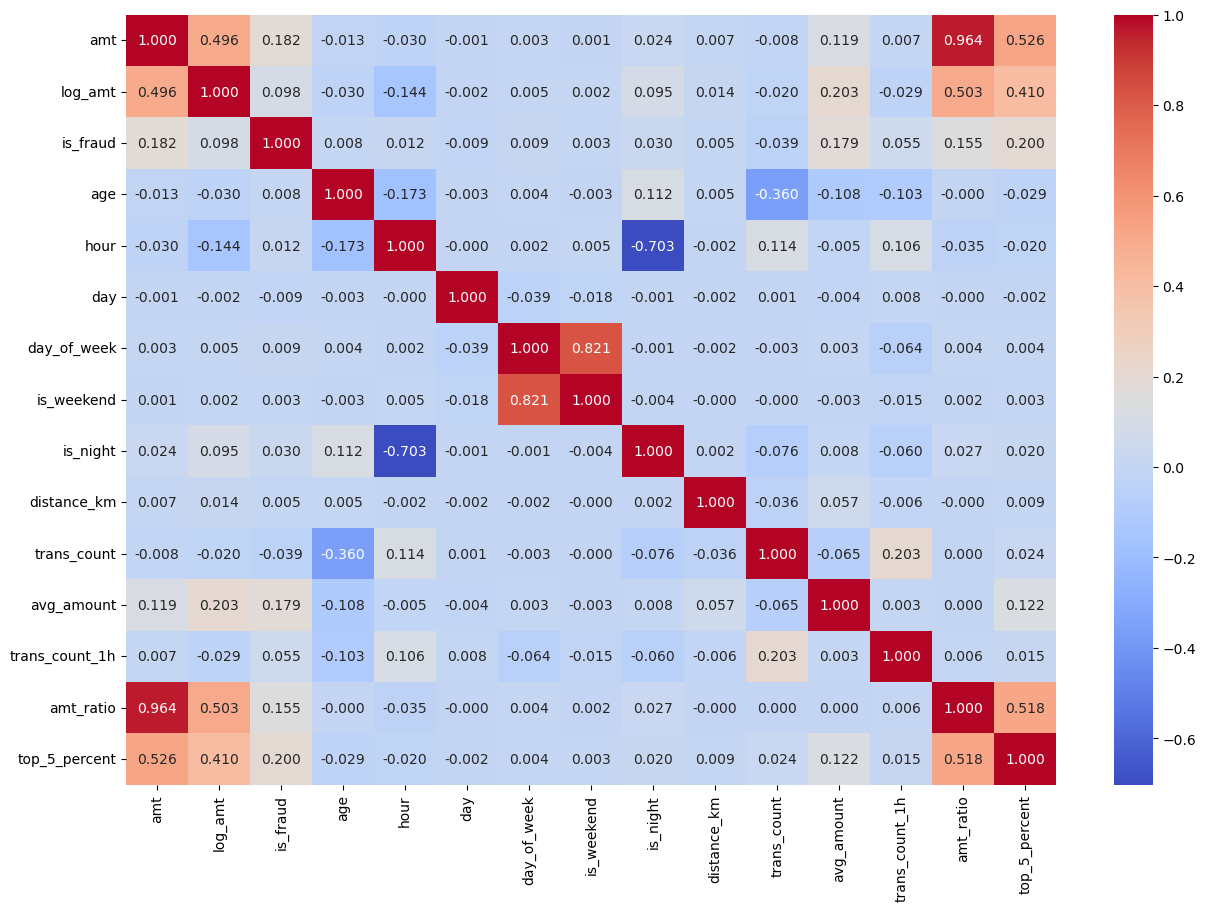

In [50]:
plt.figure(figsize=(15,10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".3f")
plt.show()

#### Đánh giá dữ liệu 
Fraud có quan hệ tương quan mạnh với
- avg_amount
- trans_count_1h 
- amt_ratio 
- top_5_percent

## 5. Data Preparation

In [51]:
le_category = LabelEncoder()
le_gender = LabelEncoder()

df['category_encoded'] = le_category.fit_transform(df['category'])
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

fraud_features = ['amt', 'log_amt', 'age',
             'hour', 'day', 'day_of_week', 'is_weekend', 'is_night',
             'distance_km', 'trans_count', 'avg_amount', 'trans_count_1h',
             'amt_ratio', 'top_5_percent']

X = df[fraud_features]
y = df['is_fraud']


In [52]:
# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train set: {X_train.shape[0]:,} samples')
print(f'Test set: {X_test.shape[0]:,} samples')
print(f'\nTrain - Fraud ratio: {y_train.mean()*100:.2f}%')
print(f'Test  - Fraud ratio: {y_test.mean()*100:.2f}%')


Train set: 444,575 samples
Test set: 111,144 samples

Train - Fraud ratio: 0.39%
Test  - Fraud ratio: 0.39%


In [53]:
# SMOTE cân bằng dữ liệu
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nTrước SMOTE: {X_train.shape[0]:,} samples')
print(f'Legit: {(y_train == 0).sum():,}')
print(f'Fraud: {(y_train == 1).sum():,}')
print(f'\nSau SMOTE: {X_train_sm.shape[0]:,} samples')
print(f'Non Fraud: {(y_train_sm == 0).sum():,}')
print(f'Fraud: {(y_train_sm == 1).sum():,}')


Trước SMOTE: 444,575 samples
Legit: 442,859
Fraud: 1,716

Sau SMOTE: 885,718 samples
Non Fraud: 442,859
Fraud: 442,859


In [54]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

## 6. Machine Learning 
1. *Logistic Regression*
2. *Decision Tree*
3. *Random Forest*
4. *XGBoost*
5. *LightGBM*

In [55]:
results = {}

def train_and_evaluate(name, model, X_tr, X_te, y_tr, y_te):
    print(f'\n{'='*60}')
    print(f'Training: {name}')
    print(f'{'='*60}')

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1_score': f1, 'auc_roc': auc
    }

    print(f'\n Kết quả:')
    print(f'   Accuracy:  {acc:.4f}')
    print(f'   Precision: {prec:.4f}')
    print(f'   Recall:    {rec:.4f}')
    print(f'   F1-Score:  {f1:.4f}')
    print(f'   AUC-ROC:   {auc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=['Non Fraud', 'Fraud']))

    return model


### 6.1 Logistic Regression

In [56]:
logistic_reg = train_and_evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, X_test_scaled, y_train_sm ,y_test
)


Training: Logistic Regression

 Kết quả:
   Accuracy:  0.9251
   Precision: 0.0400
   Recall:    0.7995
   F1-Score:  0.0761
   AUC-ROC:   0.9102

Classification Report:
              precision    recall  f1-score   support

   Non Fraud       1.00      0.93      0.96    110715
       Fraud       0.04      0.80      0.08       429

    accuracy                           0.93    111144
   macro avg       0.52      0.86      0.52    111144
weighted avg       1.00      0.93      0.96    111144



### 6.2 Decision Tree

In [57]:
dec_tree = train_and_evaluate(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=10, min_samples_split=20, random_state=42),
    X_train_scaled, X_test_scaled, y_train_sm, y_test
)


Training: Decision Tree

 Kết quả:
   Accuracy:  0.9637
   Precision: 0.0796
   Recall:    0.7949
   F1-Score:  0.1447
   AUC-ROC:   0.9345

Classification Report:
              precision    recall  f1-score   support

   Non Fraud       1.00      0.96      0.98    110715
       Fraud       0.08      0.79      0.14       429

    accuracy                           0.96    111144
   macro avg       0.54      0.88      0.56    111144
weighted avg       1.00      0.96      0.98    111144



### 6.3 Random Forest

In [58]:
ran_forest = train_and_evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=10,
                           random_state=42, n_jobs=-1),
    X_train_scaled, X_test_scaled, y_train_sm, y_test
)


Training: Random Forest

 Kết quả:
   Accuracy:  0.9872
   Precision: 0.1976
   Recall:    0.7599
   F1-Score:  0.3136
   AUC-ROC:   0.9790

Classification Report:
              precision    recall  f1-score   support

   Non Fraud       1.00      0.99      0.99    110715
       Fraud       0.20      0.76      0.31       429

    accuracy                           0.99    111144
   macro avg       0.60      0.87      0.65    111144
weighted avg       1.00      0.99      0.99    111144



### 6.4 XGBoost

In [59]:
xgb = train_and_evaluate(
    "XGBoost",
    XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                  eval_metric='logloss', random_state=42, n_jobs=-1),
    X_train_scaled, X_test_scaled, y_train_sm, y_test
)


Training: XGBoost

 Kết quả:
   Accuracy:  0.9814
   Precision: 0.1504
   Recall:    0.8205
   F1-Score:  0.2542
   AUC-ROC:   0.9829

Classification Report:
              precision    recall  f1-score   support

   Non Fraud       1.00      0.98      0.99    110715
       Fraud       0.15      0.82      0.25       429

    accuracy                           0.98    111144
   macro avg       0.57      0.90      0.62    111144
weighted avg       1.00      0.98      0.99    111144



### 6.5 LightGBM

In [60]:
lgbm = train_and_evaluate(
    "LightGBM",
    LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                   random_state=42, n_jobs=-1, verbose=-1),
    X_train_scaled, X_test_scaled, y_train_sm, y_test
)


Training: LightGBM


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 Kết quả:
   Accuracy:  0.9807
   Precision: 0.1456
   Recall:    0.8205
   F1-Score:  0.2474
   AUC-ROC:   0.9815

Classification Report:
              precision    recall  f1-score   support

   Non Fraud       1.00      0.98      0.99    110715
       Fraud       0.15      0.82      0.25       429

    accuracy                           0.98    111144
   macro avg       0.57      0.90      0.62    111144
weighted avg       1.00      0.98      0.99    111144



## 7. Model Evaluation & Comparison
### 7.1 So sánh các metrics

In [61]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'], 'Precision': r['precision'],
        'Recall': r['recall'], 'F1-Score': r['f1_score'], 'AUC-ROC': r['auc_roc']
    } for name, r in results.items()
}).T

metrics_df = metrics_df.sort_values('F1-Score', ascending=False)

print(metrics_df.to_string(float_format='{:.4f}'.format))




                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Random Forest          0.9872     0.1976  0.7599    0.3136   0.9790
XGBoost                0.9814     0.1504  0.8205    0.2542   0.9829
LightGBM               0.9807     0.1456  0.8205    0.2474   0.9815
Decision Tree          0.9637     0.0796  0.7949    0.1447   0.9345
Logistic Regression    0.9251     0.0400  0.7995    0.0761   0.9102


* Model F1-Score tốt nhất: Random Forest

* Model AUC-ROC tốt nhất: XGBoost

Random Forest phù hợp khi cần giảm false positive, trong khi XGBoost và LightGBM phù hợp khi cần phát hiện tối đa giao dịch gian lận (recall cao)

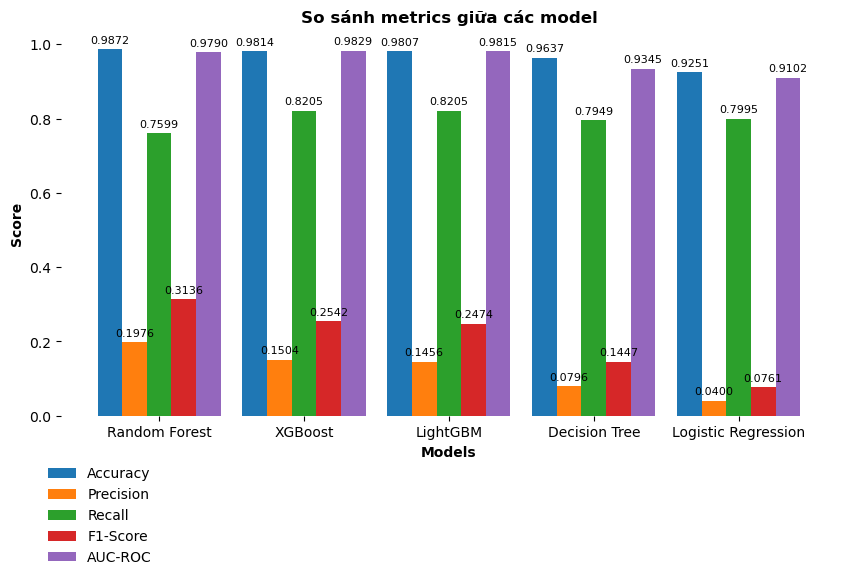

In [62]:
ax7 = metrics_df.plot(kind = 'bar',
                    figsize=(10,5),
                    width=0.85)
plt.title('So sánh metrics giữa các model',
          fontweight='bold')
plt.xticks(rotation=0)
plt.xlabel('Models',
           fontweight='bold')
plt.ylabel('Score',
           fontweight= 'bold')
ax7.set_frame_on(False)
for i in ax7.containers:
    ax7.bar_label(i,fmt= '%.4f',
                  fontsize= 8,
                  padding= 3)
plt.legend(loc='upper center', 
           bbox_to_anchor=(0.05, -0.1),                      
           fontsize=10,
           frameon=False)

plt.show()

### 7.2 Confusion Matrix

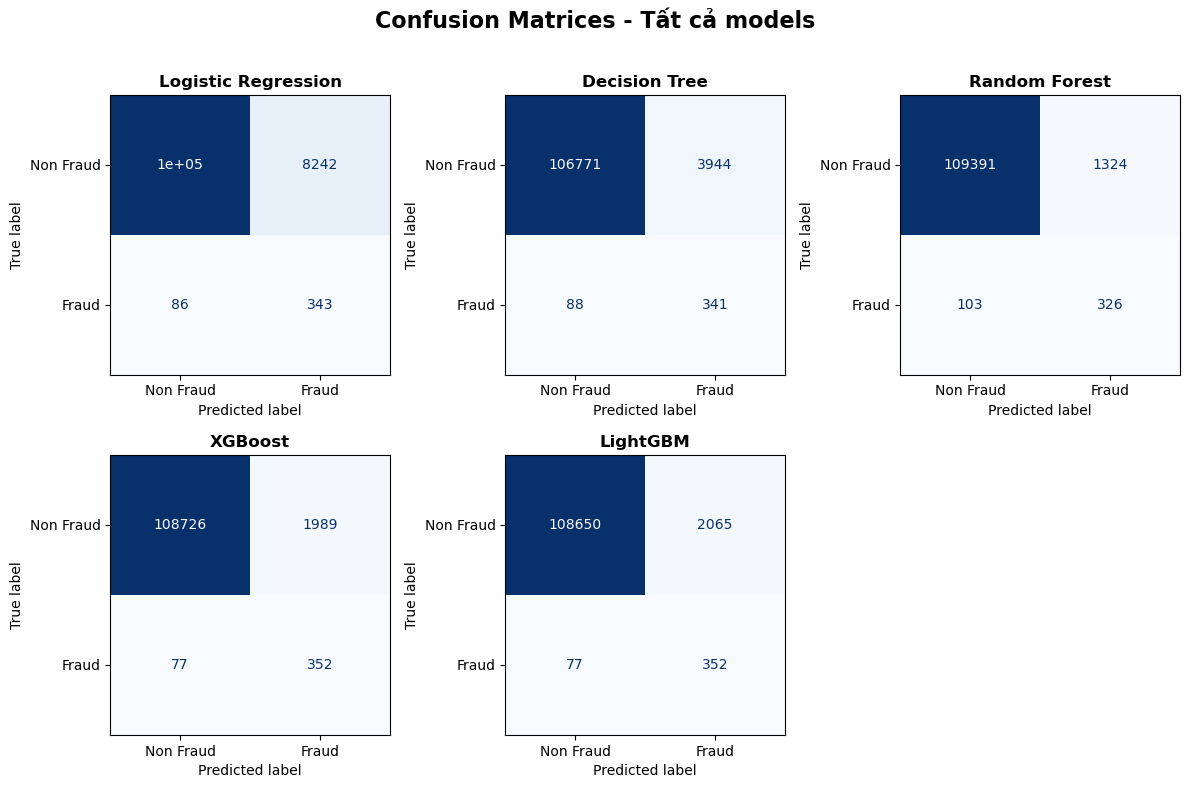

In [63]:
plt.figure(figsize=(12,8))

for i, (name, r) in enumerate(results.items()):

    ax = plt.subplot(2,3,i+1)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        r['y_pred'],
        display_labels=['Non Fraud','Fraud'],
        cmap='Blues',
        ax=ax,
        colorbar=False
    )

    plt.title(name, fontsize=12, weight='bold')

plt.suptitle("Confusion Matrices - Tất cả models\n",
             fontsize=16,
             weight='bold')
plt.tight_layout()
plt.show()

### 7.3 ROC Curve

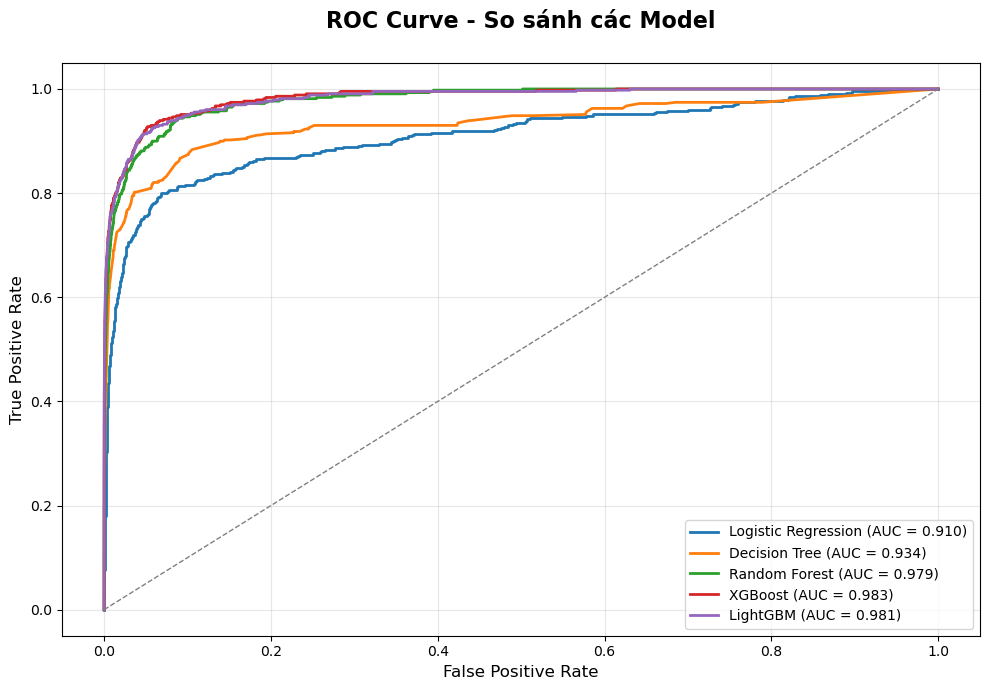

In [64]:
plt.figure(figsize=(10,7))
ax = plt.subplot(1,1,1)

for name, r in results.items():
    
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr,
             tpr,
             linewidth=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],
         [0,1],
         linestyle='--',
         color='gray',
         linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)

plt.title('ROC Curve - So sánh các Model\n',
          fontsize=16,
          weight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
rf_model = results['Random Forest']['model']
xgb_model = results['XGBoost']['model']
lgbm_model = results['LightGBM']['model']

rf_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

xgb_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

lgbm_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values('Importance', ascending=False)

### 7.3 Những Feature quan trọng theo top 3 model (Random Forest, XGBoost, LightGBM)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\2207978696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_imp.head(10),
C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\2207978696.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_imp.head(10),
C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\2207978696.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lgbm_imp.head(10),


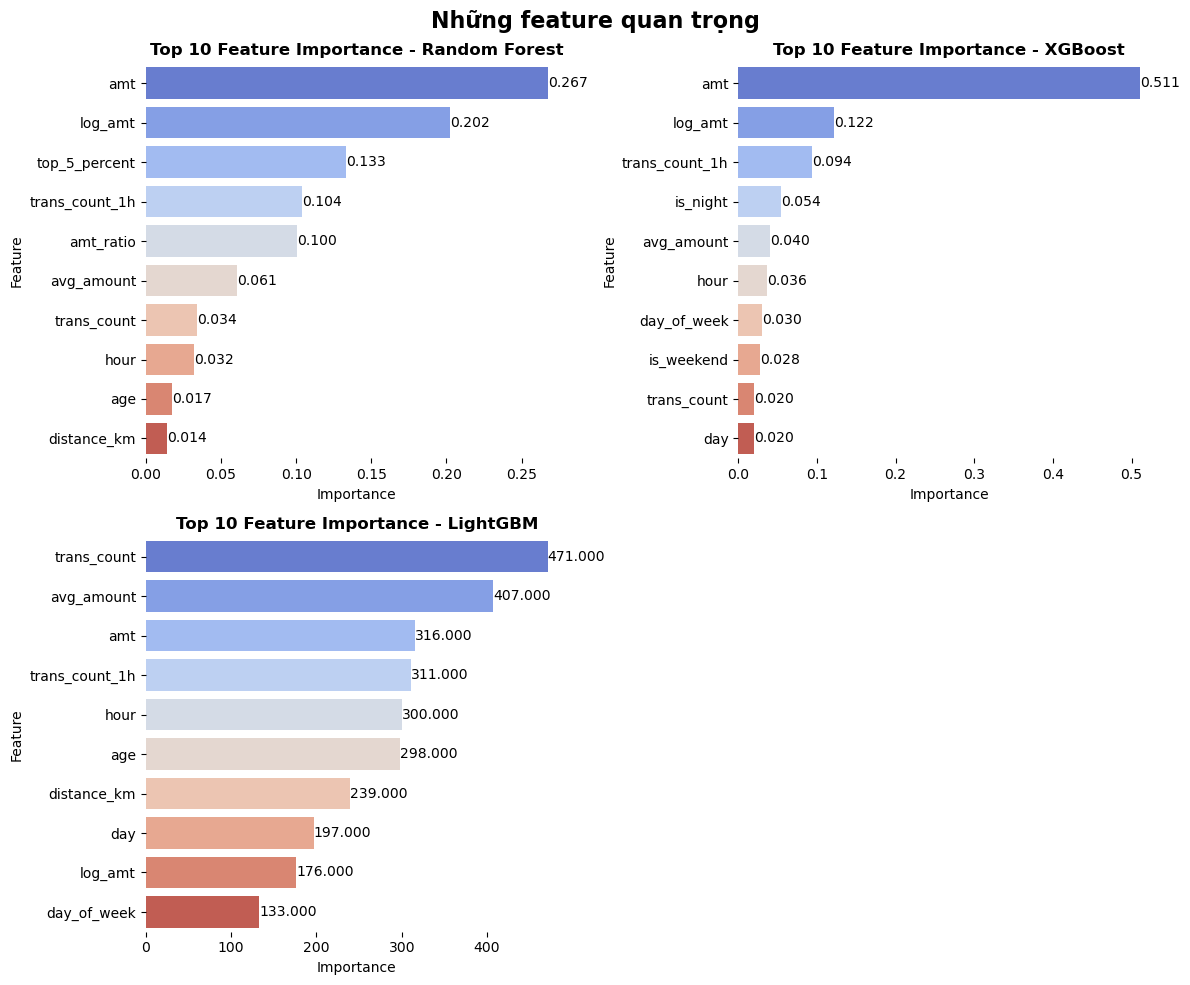

In [66]:
plt.figure(figsize=(12,10))

ax1 = plt.subplot(2,2,1)
sns.barplot(data=rf_imp.head(10),
            x='Importance',
            y='Feature',
            palette='coolwarm')
plt.title('Top 10 Feature Importance - Random Forest', weight='bold')
for i in ax1.containers:
    ax1.bar_label(i, fmt='%.3f')
ax1.set_frame_on(False)


ax2 = plt.subplot(2,2,2)
sns.barplot(data=xgb_imp.head(10),
            x='Importance',
            y='Feature',
            palette='coolwarm')
plt.title('Top 10 Feature Importance - XGBoost', weight='bold')
for i in ax2.containers:
    ax2.bar_label(i, fmt='%.3f')
ax2.set_frame_on(False)

ax3 = plt.subplot(2,2,3)
sns.barplot(data=lgbm_imp.head(10),
            x='Importance',
            y='Feature',
            palette='coolwarm')
plt.title('Top 10 Feature Importance - LightGBM', weight='bold')
for i in ax3.containers:
    ax3.bar_label(i, fmt='%.3f')
ax3.set_frame_on(False)

plt.suptitle('Những feature quan trọng',
             fontsize=16,
             weight='bold')

plt.tight_layout()
plt.show()

#### Features quan trọng theo Random Forest
1. `amt` – số tiền giao dịch
2. `log_amt` – log của số tiền giao dịch
3. `top_5_percent` – giao dịch nằm trong nhóm chi tiêu cao của khách hàng
4. `trans_count_1h` – số giao dịch trong vòng 1 giờ
5. `amt_ratio` – mức độ bất thường của số tiền so với trung bình khách hàng
6. `avg_amount` – số tiền giao dịch trung bình của khách hàng
7. `trans_count` – tổng số giao dịch của khách hàng
8. `hour` – thời điểm giao dịch trong ngày
9. `age` – tuổi khách hàng
10. `distance_km` – khoảng cách từ nhà khách hàng đến merchant

Những feature này phản ánh 3 nhóm hành vi chính:
- Hành vi chi tiêu (amt, log_amt, amt_ratio)
- Tần suất giao dịch (trans_count, trans_count_1h)
- Bất thường về vị trí và thời gian (distance_km, hour)

## 8. Kết luận và tổng kết
### Findings từ Exploratory Data Analysis (EDA)

1. **Dataset rất mất cân bằng**: Dữ liệu có sự mất cân bằng nghiêm trọng khi số lượng giao dịch gian lận chỉ chiếm một tỷ lệ rất nhỏ so với tổng số giao dịch.
2. **Số tiền giao dịch**: Fraud có xu hướng với số tiền lớn, `amt_ratio` cao bất thường
3. **Thời gian**: Fraud rate cao hơn vào ban đêm và thứ tư thứ name 
4. **Khoảng cách**: Giao dich fraud thường có khoảng cách xa từ nhà khách hàng
5. **Tần suất**: Số lần giao dịch trong 1 giờ `trans_count_1h` càng nhiều thì fraud rate càng cao
6. **Category**: Một số danh mục hàng hóa có tỷ lệ fraud cao bất thường

### Features quan trọng
1. Số tiền giao dịch: `amt`, `log_amt`, `amt_ratio`, `top_5_percent`, `avg_amount`
2. Khoảng cách từ nhà khách hàng đến điểm giao dịch: `distance_km`
3. Tần suất giao dịch: `trans_count`, `trans_count_1h`
4. Thời điểm giao dịch: `hour`, `is_night`, `is_weekend`
5. Độ tuổi giao dịch: `age`

### Model thử nghiệm
Trong số các mô hình được thử nghiệm, `Random Forest` cho kết quả tổng thể tốt nhất với F1-score, accuracy và precision cao nhất, cho thấy khả năng cân bằng giữa việc phát hiện gian lận và hạn chế cảnh báo nhầm. Trong khi đó, `XGBoost` và `LightGBM` đạt recall cao nhất, cho thấy khả năng phát hiện nhiều giao dịch gian lận hơn. Đặc biệt, `XGBoost` đạt AUC-ROC cao nhất, thể hiện khả năng phân biệt giữa giao dịch hợp lệ và gian lận tốt nhất trong các mô hình.

### Tổng kết
Kết quả cho thấy rằng các đặc trưng liên quan đến hành vi chi tiêu, vị trí giao dịch và tần suất giao dịch đóng vai trò quan trọng trong việc phát hiện gian lận. Các feature như `transaction` `amount`, `distance from home`, `transaction frequency` và `spending deviation` là những tín hiệu mạnh giúp mô hình nhận diện các giao dịch bất thường.

Trong tương lai, hiệu quả mô hình có thể được cải thiện thêm thông qua hyperparameter tuning, cross-validation và bổ sung các feature thời gian thực, nhằm xây dựng hệ thống phát hiện gian lận chính xác và ổn định hơn trong môi trường thực tế.


In [67]:
df.head()

,trans_num,trans_date_trans_time,cc_num,amt,merchant_lat,merchant_long,category,is_fraud,fist_name,last_name,...,distance_km_log,log_amt,trans_count,avg_amount,trans_count_1h,amt_ratio,top_5_percent,dist_bin,category_encoded,gender_encoded
0,f21e1a09f59c50a66735409308285b1d,2020-06-21 13:05:42,60416207185,124.66,43.0048,-108.8964,home,0,Mary,Diaz,...,4.803297,4.833580,678,66.499484,1.0,1.874601,0,100-500km,6,0
1,08f67c9765438973006f8250351d8c1f,2020-06-21 16:25:36,60416207185,78.52,43.0048,-108.8964,misc_pos,0,Mary,Diaz,...,4.803297,4.376009,678,66.499484,1.0,1.180761,0,100-500km,9,0
2,ca1f04d9d549c507356ffa8f9b43d81f,2020-06-22 07:58:33,60416207185,65.25,43.0048,-108.8964,gas_transport,0,Mary,Diaz,...,4.803297,4.193435,678,66.499484,1.0,0.981211,0,100-500km,2,0
3,d671d98fded8ca75d799959a444577a5,2020-06-22 15:32:31,60416207185,87.74,43.0048,-108.8964,kids_pets,0,Mary,Diaz,...,4.803297,4.485711,678,66.499484,1.0,1.319409,0,100-500km,7,0
4,86d346444b5b262159976aa4d8b64fbb,2020-06-23 12:28:54,60416207185,148.02,43.0048,-108.8964,personal_care,0,Mary,Diaz,...,4.803297,5.004081,678,66.499484,1.0,2.225882,0,100-500km,10,0


In [68]:
df_sample = df.sample(n=2000, random_state=42)

In [69]:
df_sample.to_csv("fraud_data_sample.csv", index=False)